In [20]:
import pathlib
import jupedsim as jps
import pedpy
from numpy.random import normal  # normal distribution of free movement speed
from shapely import Polygon, GeometryCollection, intersection
from shapely.geometry import Point
from matplotlib.patches import Circle
import random

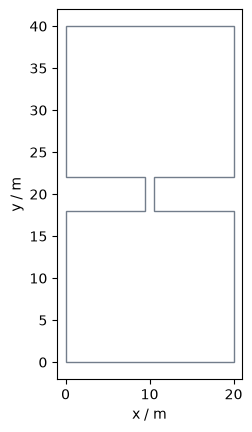

In [21]:
wings_length = 14
base_length = 20

# --- Layout selection ---
# layout = 1: base station (center booth only)
# layout = 2: same station with added kiosks and pillars (more congestion)
# layout = 3: bottleneck — wide room, wall with narrow gap, single exit
layout = 3

if layout in [1, 2]:
    # walkable areas
    north_landing = Polygon([(0, wings_length+base_length), (20, wings_length+base_length), (20, wings_length*2+base_length), (0, wings_length*2+base_length)])
    main_landing  = Polygon([(-12, wings_length), (32, wings_length), (32, wings_length+base_length), (-12, wings_length+base_length)])
    south_landing = Polygon([(0, 0), (20, 0), (20, wings_length), (0, wings_length)])

    # obstacles
    center_booth = Polygon([(6, 21), (14, 21), (14, 29), (6, 29)])

    if layout == 1:
        # Layout 1: base — center booth only
        obstacles = [center_booth]
    elif layout == 2:
        # Layout 2: center booth + two flanking kiosks + two pillars
        # Kiosks narrow the east/west corridors in the main landing
        left_kiosk  = Polygon([(-5, 20), (-2, 20), (-2, 28), (-5, 28)])
        right_kiosk = Polygon([(22, 20), (25, 20), (25, 28), (22, 28)])
        # Pillars block the direct north-south flow near the landing junctions
        left_pillar  = Polygon([(1, 19), (3, 19), (3, 21), (1, 21)])
        right_pillar = Polygon([(17, 19), (19, 19), (19, 21), (17, 21)])
        obstacles = [center_booth, left_kiosk, right_kiosk, left_pillar, right_pillar]

    base_area = north_landing.union(main_landing).union(south_landing)
    for obs in obstacles:
        base_area = base_area.difference(obs)

elif layout == 3:
    # Layout 3: bottleneck
    # Wide room, wall across the middle with a narrow 3m gap forcing crowd compression
    room = Polygon([(0, 0), (20, 0), (20, 40), (0, 40)])

    # Wall at y=18-22, gap left open from x=8.5 to x=11.5 (3m bottleneck)
    left_wall  = Polygon([(0,  18), (9.5, 18), (9.5, 22), (0,  22)])
    right_wall = Polygon([(10.5, 18), (20, 18), (20, 22), (10.5, 22)])

    # main_landing = the congestion zone (south half, where agents pile up)
    main_landing = Polygon([(0, 0), (20, 0), (20, 18), (0, 18)])

    base_area = room.difference(left_wall).difference(right_wall)

area = GeometryCollection(base_area)
walkable_area = pedpy.WalkableArea(area)
pedpy.plot_walkable_area(walkable_area=walkable_area).set_aspect("equal")


In [22]:
num_agents = 20  # total agents to spawn across all entries

if layout in [1, 2]:
    # entrances
    south_left_entrance  = Polygon([(0,  0),  (3,  0),  (3,  10), (0,  10)])
    south_right_entrance = Polygon([(17, 0),  (20, 0),  (20, 10), (17, 10)])
    north_left_entrance  = Polygon([(0,  38), (3,  38), (3,  48), (0,  48)])
    north_right_entrance = Polygon([(17, 38), (20, 38), (20, 48), (17, 48)])

    # All entry points tagged by which side they belong to
    all_entries = [
        ('south', south_left_entrance),
        ('south', south_right_entrance),
        ('north', north_left_entrance),
        ('north', north_right_entrance),
    ]

    # exits
    right_exit = Polygon([(30, 14), (32, 14), (32, 34), (30, 34)])
    left_exit  = Polygon([(-12, 14), (-10, 14), (-10, 34), (-12, 34)])
    exit_areas = [right_exit, left_exit]

    # switches
    switch_n = (10, 34)
    switch_s = (10, 14)

    # waypoints
    waypoints_n = [(4, 32), (16, 32)]
    waypoints_s = [(4, 16), (16, 16)]

elif layout == 3:
    # Bottleneck entries: agents spawn across the full south wall
    south_left_entrance  = Polygon([(0,  0), (8,  0), (8,  6), (0,  6)])
    south_right_entrance = Polygon([(12, 0), (20, 0), (20, 6), (12, 6)])

    # All entries are 'south' — everyone goes the same direction
    all_entries = [
        ('south', south_left_entrance),
        ('south', south_right_entrance),
    ]

    # Single exit: full north wall
    north_exit = Polygon([(0, 38), (20, 38), (20, 40), (0, 40)])
    exit_areas = [north_exit]

    # Waypoint at the bottleneck gap — agents must funnel through here
    gap_waypoint = (10, 20)

    # Switch: gathering point before the wall
    switch_s = (10, 10)

def random_point_in_polygon(poly, boundary_margin=0.3, max_attempts=500):
    """Return a uniformly random (x, y) inside poly using rejection sampling.
    Shrinks the polygon inward by boundary_margin before sampling so JuPedSim
    geometry boundary constraints (distance > 0.2) are never violated."""
    inner = poly.buffer(-boundary_margin)
    if inner.is_empty:
        raise ValueError(f"Polygon too small to shrink by {boundary_margin}m")
    minx, miny, maxx, maxy = inner.bounds
    for _ in range(max_attempts):
        p = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
        if inner.contains(p):
            return (p.x, p.y)
    raise RuntimeError(f"Could not sample a point inside polygon after {max_attempts} attempts.")


In [23]:
def plot_simulation_configuration(
    walkable_area, spawning_area, starting_positions, exit_area
):
    axes = pedpy.plot_walkable_area(walkable_area=walkable_area)
    axes.fill(*spawning_area.exterior.xy, color="lightgrey")
    axes.fill(*exit_area.exterior.xy, color="indianred")
    axes.scatter(*zip(*starting_positions))
    axes.set_xlabel("x/m")
    axes.set_ylabel("y/m")
    axes.set_aspect("equal")


In [24]:
trajectory_file = "corner.sqlite"  # output file
simulation = jps.Simulation(
    model=jps.AnticipationVelocityModel(),
    geometry=area,
    trajectory_writer=jps.SqliteTrajectoryWriter(
        output_file=pathlib.Path(trajectory_file)
    ),
)


In [25]:
def least_targeted(
    simulation: jps.Simulation, switch_id, waypoint_ids, exit_id
):
    """Build a journey with least targeted transitions for a given simulation."""

    journey = jps.JourneyDescription([switch_id, *waypoint_ids, exit_id])
    # switch ---> least targeted waypoint
    journey.set_transition_for_stage(
        switch_id,
        jps.Transition.create_least_targeted_transition(waypoint_ids),
    )
    # from all waypoints ---> exit
    for waypoint_id in waypoint_ids:
        journey.set_transition_for_stage(
            waypoint_id, jps.Transition.create_fixed_transition(exit_id)
        )

    journey_id = simulation.add_journey(journey)
    return journey_id


In [26]:
exit_ids = []
for exit_area in exit_areas:
    exit_ids.append(simulation.add_exit_stage(exit_area.exterior.coords[:-1]))

if layout in [1, 2]:
    left_exit_id  = exit_ids[0]
    right_exit_id = exit_ids[1]

    south_switch_id = simulation.add_waypoint_stage(switch_s, 1)
    north_switch_id = simulation.add_waypoint_stage(switch_n, 1)

    south_waypoint_ids = [
        simulation.add_waypoint_stage(waypoint, 1)
        for waypoint in waypoints_s
    ]

    north_waypoint_ids = [
        simulation.add_waypoint_stage(waypoint, 1)
        for waypoint in waypoints_n
    ]

    # SOUTH JOURNEYS (one to left, one to right)
    south_journey_toleft_id  = least_targeted(simulation, south_switch_id, south_waypoint_ids, left_exit_id)
    south_journey_toright_id = least_targeted(simulation, south_switch_id, south_waypoint_ids, right_exit_id)

    # NORTH JOURNEYS
    north_journey_toleft_id  = least_targeted(simulation, north_switch_id, north_waypoint_ids, left_exit_id)
    north_journey_toright_id = least_targeted(simulation, north_switch_id, north_waypoint_ids, right_exit_id)

elif layout == 3:
    north_exit_id = exit_ids[0]

    # Switch: agents gather south of the wall before funneling through
    south_switch_id = simulation.add_waypoint_stage(switch_s, 1)

    # Waypoint at the gap — the actual bottleneck point
    gap_waypoint_id = simulation.add_waypoint_stage(gap_waypoint, 1)

    # Single journey: switch -> gap -> exit
    bottleneck_journey = jps.JourneyDescription([south_switch_id, gap_waypoint_id, north_exit_id])
    bottleneck_journey.set_transition_for_stage(
        south_switch_id,
        jps.Transition.create_fixed_transition(gap_waypoint_id),
    )
    bottleneck_journey.set_transition_for_stage(
        gap_waypoint_id,
        jps.Transition.create_fixed_transition(north_exit_id),
    )
    bottleneck_journey_id = simulation.add_journey(bottleneck_journey)


In [27]:
spawned = 0       # total agents spawned so far
max_frames = 10000
frame = 0

spawn_interval = 100

while frame < max_frames:

    if frame % spawn_interval == 0 and spawned < num_agents:
        # Randomly pick an entry point; side determines journey + switch
        side, entry_poly = random.choice(all_entries)
        pos = random_point_in_polygon(entry_poly)
        v0  = float(normal(1.34, 0.05, 1)[0])

        if layout in [1, 2]:
            if side == 'south':
                simulation.add_agent(
                    jps.AnticipationVelocityModelAgentParameters(
                        journey_id=random.choice([south_journey_toleft_id, south_journey_toright_id]),
                        stage_id=south_switch_id,
                        position=pos,
                        desired_speed=v0,
                    )
                )
            else:  # north
                simulation.add_agent(
                    jps.AnticipationVelocityModelAgentParameters(
                        journey_id=random.choice([north_journey_toleft_id, north_journey_toright_id]),
                        stage_id=north_switch_id,
                        position=pos,
                        desired_speed=v0,
                    )
                )

        elif layout == 3:
            # All agents take the single bottleneck journey
            simulation.add_agent(
                jps.AnticipationVelocityModelAgentParameters(
                    journey_id=bottleneck_journey_id,
                    stage_id=south_switch_id,
                    position=pos,
                    desired_speed=v0,
                )
            )

        spawned += 1

    simulation.iterate()
    frame += 1

    # Optional: break early if everything done
    if spawned >= num_agents and simulation.agent_count() == 0:
        break


In [28]:
#test

In [29]:
from jupedsim.internal.notebook_utils import read_sqlite_file

trajectory_data, walkable_area = read_sqlite_file(trajectory_file)

INFO - Animation.save using <class 'matplotlib.animation.HTMLWriter'>


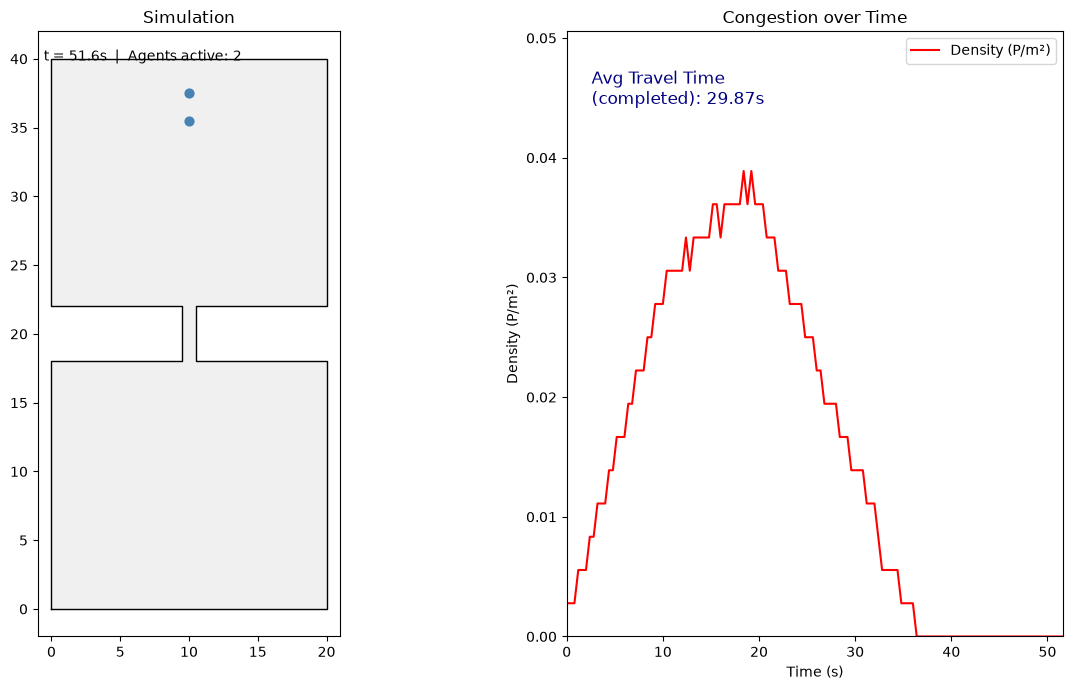

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from shapely.geometry import Point
from IPython.display import HTML

df = trajectory_data.data
fps = trajectory_data.frame_rate
dt = 1 / fps
nth = 10
frames = sorted(df['frame'].unique())[::nth]

# Pre-compute per-agent entry/exit
agent_info = df.groupby('id')['frame'].agg(first_frame='min', last_frame='max')

# Pre-compute metrics for every sampled frame
metrics = []
for f in frames:
    frame_df = df[df['frame'] == f]
    in_area = frame_df[frame_df.apply(lambda r: Point(r.x, r.y).within(main_landing), axis=1)]
    density = len(in_area) / main_landing.area
    # https://arxiv.org/abs/0911.2165 - usual computation for density is P/m^2 (Number of agents over area squared)
    completed = agent_info[agent_info['last_frame'] <= f]
    avg_tt = ((completed['last_frame'] - completed['first_frame']) * dt).mean() if len(completed) > 0 else float('nan')
    metrics.append({'density': density, 'avg_tt': avg_tt, 'count': len(frame_df)})

# --- Figure setup ---
fig, (ax_sim, ax_metrics) = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [2, 1]})

# Draw walkable area
boundary = walkable_area.polygon
bx, by = boundary.exterior.xy
ax_sim.fill(bx, by, color='#f0f0f0', zorder=0)
ax_sim.plot(bx, by, 'k-', lw=1, zorder=1)
for interior in boundary.interiors:
    ix, iy = interior.xy
    ax_sim.fill(ix, iy, color='gray', zorder=2)

agents_scatter = ax_sim.scatter([], [], c='steelblue', s=40, zorder=3)
frame_text = ax_sim.text(0.02, 0.97, '', transform=ax_sim.transAxes, va='top', fontsize=10)
ax_sim.set_aspect('equal')
ax_sim.set_title('Simulation')

# Metrics panel
max_density = max(m['density'] for m in metrics) or 0.1
density_line, = ax_metrics.plot([], [], 'r-', label='Density (P/m²)')
avg_tt_text = ax_metrics.text(0.05, 0.88, '', transform=ax_metrics.transAxes, fontsize=12, color='navy')
ax_metrics.set_xlim(0, frames[-1] * dt)
ax_metrics.set_ylim(0, max_density * 1.3)
ax_metrics.set_xlabel('Time (s)')
ax_metrics.set_ylabel('Density (P/m²)')
ax_metrics.set_title('Congestion over Time')
ax_metrics.legend(loc='upper right')

density_x, density_y = [], []

def init():
    agents_scatter.set_offsets(np.empty((0, 2)))
    density_line.set_data([], [])
    return agents_scatter, density_line, frame_text, avg_tt_text

def update(i):
    f = frames[i]
    m = metrics[i]
    t = f * dt

    frame_df = df[df['frame'] == f]
    agents_scatter.set_offsets(frame_df[['x', 'y']].values if len(frame_df) > 0 else np.empty((0, 2)))
    frame_text.set_text(f't = {t:.1f}s  |  Agents active: {m["count"]}')

    density_x.append(t)
    density_y.append(m['density'])
    density_line.set_data(density_x, density_y)

    tt_str = f'{m["avg_tt"]:.2f}s' if not np.isnan(m['avg_tt']) else 'N/A'
    avg_tt_text.set_text(f'Avg Travel Time\n(completed): {tt_str}')

    return agents_scatter, density_line, frame_text, avg_tt_text

ani = animation.FuncAnimation(fig, update, frames=len(frames), init_func=init, blit=True, interval=100)
plt.tight_layout()
HTML(ani.to_jshtml())

# Add what parameters to this simulation
    # entry and exit points, num of agents
# diff layouts na, add obstacles, add stuff that might congest the area
# then have a plan for what's next
